# Feature Engineering 2

本 Notebook 承接 `04_feature_engineering.ipynb`，记录 Feature Engineering Round 2 从**修正筛选标尺**到**确定最终特征集合**的完整过程：以 FE10 为固定 Reference，用 NULL / Negative-Control 校准 feature-addition noise，再用 6 个完整 5-Fold 实验验证 numerical、categorical interaction 与历史 Audit 分支，最后通过 R_GROUP LOO 与单特征确认把方案收敛为 **FE10 + FE25**。

---

## Table of Contents

1. [实验背景与正式 Reference](#r2-num-setup)
   - 1.1 [Round 1 在哪里结束](#r2-num-contract)
   - 1.2 [导入依赖与定位项目路径](#r2-num-imports)
2. [重新设计筛选策略](#r2-strategy)
3. [FE20–FE46 候选目录与实现假设](#r2-num-catalog)
   - 3.1 [FE20–FE29：Numerical](#r2-num-catalog)
   - 3.2 [FE30–FE46：Categorical interactions](#r2-cat-catalog)
   - 3.3 [交互实现与实际模型设置](#r2-cat-implementation)
4. [受控实验协议与运行顺序](#r2-num-run)
   - 4.1 [运行命令](#r2-run-commands)
5. [NULL / Negative-Control 完整结果](#r2-null-results)
   - 5.1 [两类 NULL 的设计目的](#r2-null-design)
   - 5.2 [NULL 校准后的启发式决策线](#r2-null-decision-line)
6. [第一阶段 6 个实验的完整 5-Fold 证据](#r2-num-results)
   - 6.1 [Numerical 分支](#r2-num-analysis)
   - 6.2 [Categorical interaction 分支](#r2-cat-results)
   - 6.3 [整体决策与解释边界](#r2-num-decisions)
7. [R_GROUP LOO 与单特征确认](#r2-loo)
8. [最终模型与提交文件](#r2-final-model)
   - 8.1 [准备全量数据与最终特征](#r2-final-data)
   - 8.2 [训练最终模型](#r2-final-training)
   - 8.3 [生成、检查并保存提交文件](#r2-final-submission)
9. [Feature Engineering 最终结论](#r2-num-next)
---

<a id="r2-num-setup" name="r2-num-setup"></a>

## 1. 实验背景与正式 Reference

<a id="r2-num-contract" name="r2-num-contract"></a>

### 1.1 Round 1 在哪里结束

`04_feature_engineering.ipynb` 已经完成从 19 组候选到 FE10 的第一轮收敛。FE10 把总屏幕时间中没有被社交、游戏、工作/学习三个字段解释的部分单独交给模型：

```python
unknown_activity_time = (
    daily_screen_time_hours
    - social_media_hours
    - gaming_hours
    - work_study_hours
)
```

它是当前最简单、最稳定的 Feature Reference：

| 项目 | 结果 |
|---|---:|
| Reference | **FE10 — `unknown_activity_time`** |
| 5-Fold CV AUC | **`0.964629 ± 0.000523`** |
| Mean Δ vs BASE | **`+0.000621`** |
| 正向 Fold | **5/5** |
| Public LB | **`0.96606`** |

Round 2 不再问“candidate 是否优于原始 BASE”，而是统一回答：

```text
delta_vs_reference
= AUC(FE10 + candidate / feature group) - AUC(FE10)
```

比较必须发生在同一个 Fold 下。这样可以抵消不同 Fold 本身难度的差异，把注意力集中到“多加这些特征后，模型究竟移动了多少”。

Round 2 的目标不是继续堆很多变换，而是回答两个更窄的问题：FE10 之外是否仍有稳定的时间预算增量，以及显式 categorical interaction 是否能补充 CatBoost 已有的非线性建模能力。

<a id="r2-num-imports" name="r2-num-imports"></a>

### 1.2 导入依赖与定位项目路径

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from catboost import CatBoostClassifier
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.round2_features import (
    make_round2_features,
)

NULL_RESULTS_DIR = PROJECT_ROOT / "results" / "noise_calibration"
ROUND2_RESULTS_DIR = PROJECT_ROOT / "results" / "round2" / "first_stage"
ROUND2_LOO_DIR = PROJECT_ROOT / "results" / "round2" / "r_group_loo"
ROUND2_SINGLE_DIR = PROJECT_ROOT / "results" / "round2" / "r_group_single"
NULL_SUMMARY_PATH = NULL_RESULTS_DIR / "summary.csv"
ROUND2_SUMMARY_PATH = ROUND2_RESULTS_DIR / "summary.csv"

<a id="r2-strategy" name="r2-strategy"></a>

## 2. 重新设计筛选策略

Round 1 曾用 `CV_STD = 0.000473` 衡量候选增量，但它来自 BASE 五个 Fold 的**绝对 AUC 标准差**。Round 2 比较的是相同 Fold 下 `candidate - FE10` 的配对差值，两者不是同一类波动。已有实验中，FE09、FE10、FE19 的 paired-delta Std 只有约 `0.000042–0.000092`，继续用 `0.000473` 会把一些边缘信号机械压成 Reject。

另一个问题是 multiple comparisons：如果几十个候选都只跑 Fold 1，再从中选择最好看的结果，即使真实效应全为零，也容易挑中一个偶然的正数，形成 winner's curse。因此 Round 2 不再使用“27 candidates × Fold 1 排名”，而是先验证较少的机制分支。

| 名称 | 在实验树中的含义 | 是否直接进入第一阶段 |
|---|---|---|
| NULL / Negative-Control | 测量多加无信息列时模型自身会漂多少 | 是，但不属于 FE 候选 |
| Active | 当前先验最高、直接进入完整 5-Fold 的成员 | 是 |
| Conditional Reserve | 只有同方向 Active family 成立后才可能唤醒 | 否 |
| Audit | 因旧标尺可能误判而获得一次公平复审的历史候选 | 是 |

<a id="r2-num-catalog" name="r2-num-catalog"></a>

## 3. FE20–FE46 候选目录与实现假设

### 3.1 FE20–FE29：Numerical

为方便阅读，使用以下缩写：

```text
D  = daily_screen_time_hours
S  = social_media_hours
G  = gaming_hours
W  = work_study_hours
WK = weekend_screen_time
U  = FE10 = D - S - G - W
```

本轮不再把所有候选逐个做 Fold 1 排名。Active / Audit 先按机制组成完整 5-Fold 实验；Conditional Reserve 只有在同方向实验成立后才考虑。

| 思路 | 候选 | 第一阶段实验 | 想回答的问题 |
|---|---|---|---|
| Residual / partial residual | FE20–FE25 | `R_GROUP` = FE20 + FE22 + FE25 | FE10 之外是否仍有更容易被树利用的时间预算方向？ |
| Linear balance | FE26 | FE26 单独 | leisure 与 work/study 的差是否提供独立行为轴？ |
| Screen aggregation | FE27 | FE27 单独 | 日常与周末屏幕时间的均值是否比原始两列更稳定？ |
| Ratio Audit | FE28–FE29 | `O_GROUP` = FE28 + FE29 | 旧 FE07 / FE16 的单折弱正信号是否能在完整五折复现？ |

In [3]:
NUMERICAL_FEATURE_INFO = {
    "FE20": ("D - S", "Active", "R_GROUP", "去除社交后的 screen residual 可能补充 FE10。"),
    "FE21": ("D - G", "Conditional Reserve", "R_GROUP 成功后考虑", "检验去除 gaming 后的 residual。"),
    "FE22": ("D - W", "Active", "R_GROUP", "去除工作学习后的 screen residual 可能保留娱乐与未知活动。"),
    "FE23": ("D - S - G", "Conditional Reserve", "R_GROUP 成功后考虑", "近似 W + U，检验 work 与未知活动的联合方向。"),
    "FE24": ("D - S - W", "Conditional Reserve", "R_GROUP 成功后考虑", "近似 G + U，检验 gaming 与未知活动的联合方向。"),
    "FE25": ("D - G - W", "Active", "R_GROUP", "近似 S + U，检验 social 与未知活动的联合方向。"),
    "FE26": ("S + G - W", "Active", "单独 5-Fold", "leisure 与 work/study 的斜向差可能刻画用途失衡。"),
    "FE27": ("mean(D, WK)", "Active", "单独 5-Fold", "两个屏幕时间测量的均值可能降低单列噪声。"),
    "FE28": ("W / D", "Audit", "O_GROUP", "公平复审旧 FE07 的弱正向 Fold 1 信号。"),
    "FE29": ("(S + G) / D", "Audit", "O_GROUP", "公平复审旧 FE16 的弱正向 Fold 1 信号。"),
}

catalog_rows = []
for feature_id, (definition, status, experiment, hypothesis) in NUMERICAL_FEATURE_INFO.items():
    catalog_rows.append({
        "特征": feature_id,
        "定义": definition,
        "状态": status,
        "第一阶段用途": experiment,
        "建模假设": hypothesis,
    })

numerical_catalog = pd.DataFrame(catalog_rows)
display(numerical_catalog)

,特征,定义,状态,第一阶段用途,建模假设
0,FE20,D - S,Active,R_GROUP,去除社交后的 screen residual 可能补充 FE10。
1,FE21,D - G,Conditional Reserve,R_GROUP 成功后考虑,检验去除 gaming 后的 residual。
2,FE22,D - W,Active,R_GROUP,去除工作学习后的 screen residual 可能保留娱乐与未知活动。
3,FE23,D - S - G,Conditional Reserve,R_GROUP 成功后考虑,近似 W + U，检验 work 与未知活动的联合方向。
4,FE24,D - S - W,Conditional Reserve,R_GROUP 成功后考虑,近似 G + U，检验 gaming 与未知活动的联合方向。
5,FE25,D - G - W,Active,R_GROUP,近似 S + U，检验 social 与未知活动的联合方向。
6,FE26,S + G - W,Active,单独 5-Fold,leisure 与 work/study 的斜向差可能刻画用途失衡。
7,FE27,"mean(D, WK)",Active,单独 5-Fold,两个屏幕时间测量的均值可能降低单列噪声。
8,FE28,W / D,Audit,O_GROUP,公平复审旧 FE07 的弱正向 Fold 1 信号。
9,FE29,(S + G) / D,Audit,O_GROUP,公平复审旧 FE16 的弱正向 Fold 1 信号。


<a id="r2-cat-catalog" name="r2-cat-catalog"></a>

### 3.2 FE30–FE46：Categorical interactions

| ID | 定义 | 状态 | 第一阶段用途 |
|---|---|---|---|
| FE30 | gender × gaming | Active | CAT_NUM_GROUP |
| FE31 | gender × social | Active | CAT_NUM_GROUP |
| FE32 | gender × screen | Conditional Reserve+ | Gender 方向成立后优先 |
| FE33 | gender × FE10 | Conditional Reserve | Gender 方向成立后考虑 |
| FE34 | stress × sleep | Active | CAT_NUM_GROUP |
| FE35 | stress × screen | Conditional Reserve+ | Stress 方向成立后优先 |
| FE36 | stress × FE10 | Conditional Reserve | Stress 方向成立后考虑 |
| FE37 | stress × work | Conditional Reserve（低优先） | Stress 方向明显成立后 |
| FE38 | stress × social | Conditional Reserve+ | Stress 方向成立后优先 |
| FE39 | impact × work | Active | CAT_NUM_GROUP |
| FE40 | impact × screen | Active | CAT_NUM_GROUP |
| FE41 | impact × FE10 | Conditional Reserve | Impact 方向成立后考虑 |
| FE42 | impact × social | Conditional Reserve+ | Impact 方向成立后优先 |
| FE43 | gender × stress | Active | CAT2_GROUP |
| FE44 | gender × impact | Active | CAT2_GROUP |
| FE45 | stress × impact | Active | CAT2_GROUP，先验最高的二阶组合 |
| FE46 | gender × stress × impact | Conditional Reserve | CAT2_GROUP 成立后才唤醒 |

第一阶段的 categorical 问题被压缩成两个 group：`CAT_NUM_GROUP = FE30 + FE31 + FE34 + FE39 + FE40` 检查人工 gated numerical interaction 这一方向；`CAT2_GROUP = FE43 + FE44 + FE45` 检查显式二阶 categorical combination。

<a id="r2-cat-implementation" name="r2-cat-implementation"></a>

### 3.3 交互实现与实际模型设置

Categorical × numerical 不使用没有真实顺序含义的 `category_code × numerical`。以 FE30 为例，`gender × gaming` 被展开为 `gaming_by_gender__Female`、`__Male`、`__Other`、`__Missing`：类别匹配时保留原 numerical value，不匹配时为 NaN；原始 category、原始 numerical 与 numerical missing flag 同时保留。这样既不伪造类别顺序，也能区分类别不匹配和 numerical 自身缺失。

Categorical × categorical 使用显式字符串组合，例如 `Female__High`，并把新列明确加入 CatBoost `cat_features`。

<a id="r2-num-run" name="r2-num-run"></a>

## 4. 受控实验协议与运行顺序

所有正式实验固定使用同一套 Fold 和显式模型参数，只改变 FE10 之外新增的特征。现场 `protocol.json` 记录的核心设置如下：

| 项目 | 固定值 |
|---|---|
| Reference | 同 Fold 的 FE10 JSON |
| CV | `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)` |
| CatBoost | 10,000 iterations、learning rate 0.05、depth 6、AUC |
| Early stopping | 200 rounds |
| CV split seed / model seed / thread count | 42 / 42 / 10 |
| Round 2 protocol / config | `catboost_fe10_round2_first_stage_v1` / `07f0d4012220` |
| 核心指标 | 同 Fold `delta_vs_reference` |

### 从校准到归因

```text
Stage 0  参数、categorical dtype 与实际模型设置检查
   ↓
Stage 1  NULL-A 5-Fold + 两个 NULL-B seed × 5-Fold = 15 fits
   ↓
Stage 2  FE27 → R_GROUP → FE26 → CAT_NUM_GROUP → CAT2_GROUP → O_GROUP
         6 个实验 × 5-Fold = 30 fits
   ↓
Stage 3  只有通过的 group 进入 LOO；Reserve 不自动运行
   ↓
Stage 4  组装最小候选集合
```

第一阶段加上 NULL 共 45 fits。完整五折直接验证机制方向，避免从大量单 Fold 结果中挑选最幸运的候选。

<a id="r2-run-commands" name="r2-run-commands"></a>

### 4.1 运行命令

以下命令均从项目根目录运行，会训练对应实验并在 `results/round2/` 写入或更新逐 Fold JSON。前一组完成 NULL 校准和六个第一阶段实验并汇总结果；确认 `R_GROUP` 通过后，再运行后一组 LOO 归因实验并汇总。

```bash
python -m src.noise_calibration
python -m src.round2_experiment FE27 R_GROUP FE26 CAT_NUM_GROUP CAT2_GROUP O_GROUP
python -m src.summarize_round2

python -m src.round2_experiment R_MINUS_FE20 R_MINUS_FE22 R_MINUS_FE25
python -m src.summarize_round2 --results-dir results/round2/r_group_loo
```

<a id="r2-null-results" name="r2-null-results"></a>

## 5. NULL / Negative-Control 完整结果

NULL 不是候选特征，也不会进入最终 feature set。本轮判断的是相对 FE10 的 paired AUC delta，因此需要先测量“只新增一个无用列时”模型本身会有多大波动，而不能沿用 BASE 的绝对 AUC 波动。三组 control 均跑完整 5-Fold，共 15 fits。

<a id="r2-null-design" name="r2-null-design"></a>

### 5.1 两类 NULL 的设计目的

- **NULL-A：冗余 control。** 对 `daily_screen_time_hours`（`D`）新增 `2 × D - 3`。它与原列严格单调等价，不会带来新的逐行信息；但它确实多提供了一个可被树选择的冗余列。因此它测量的是：在没有新信息时，仅由冗余特征竞争 split、跨 Fold 训练差异与 early stopping 造成的 paired delta 波动。
- **NULL-B：置换 negative control。** 以 seed 1001、1002 分别打乱同一列 `D`。置换后数值分布、尺度、dtype 和缺失比例不变，但行与行之间的原始对应关系被破坏，因而不保留可利用的信息。它测量的是：一个表面格式完全合理、实际无信息的数值列进入模型后带来的扰动；使用两个 seed 也避免把一次置换的偶然结果当作普遍规律。

两者不能互相替代：NULL-A 只覆盖“信息已存在但重复”的情形，NULL-B 覆盖“格式相同但信息被破坏”的情形。后续校准保留各 control 自己的 Fold 内波动再合并，而不把 15 个 delta 当作同一种、同分布的样本直接混合。置换列也不要求平均 delta 恰好为零：它可能因增加无信息 split 选择而轻微扰动模型。

下表从逐折 JSON 重新计算 sample standard deviation（`ddof=1`），便于和 Round 2 表格一致；用于启发式门槛的 `σ_null` 则沿用 NULL 保存汇总中的 population Std（`ddof=0`）。两种口径必须明确标注，它们只改变 Std 的展示与校准计算，不改变任何 AUC 或 paired delta。

In [7]:
if not NULL_SUMMARY_PATH.exists():
    raise FileNotFoundError("未找到 NULL summary.csv。")

null_records = [
    json.loads(path.read_text(encoding="utf-8"))
    for path in sorted(NULL_RESULTS_DIR.glob("null_*_fold*.json"))
]
null_folds = pd.DataFrame(null_records)

if len(null_folds) != 15:
    raise ValueError(f"NULL 结果应为 15 条，当前为 {len(null_folds)} 条。")

null_analysis = (
    null_folds.groupby("experiment_id")
    .agg(
        mean_auc=("auc", "mean"),
        mean_delta=("delta_vs_reference", "mean"),
        positive_folds=("delta_vs_reference", lambda values: int((values > 0).sum())),
        delta_std=("delta_vs_reference", lambda values: values.std(ddof=0)),
        mean_abs_delta=("delta_vs_reference", lambda values: values.abs().mean()),
        max_abs_delta=("delta_vs_reference", lambda values: values.abs().max()),
    )
    .reset_index()
)

null_view = null_analysis.rename(columns={
    "experiment_id": "实验",
    "mean_auc": "平均 AUC",
    "mean_delta": "平均 Δ",
    "positive_folds": "正向 Fold",
    "delta_std": "Δ Std (ddof=0；用于门槛)",
    "mean_abs_delta": "Mean |Δ|",
    "max_abs_delta": "Max |Δ|",
})

display(null_view)

,实验,平均 AUC,平均 Δ,正向 Fold,Δ Std (ddof=1),Mean |Δ|,Max |Δ|
0,NULL_A_AFFINE,0.964644,0.000016,3,0.000079,0.000051,0.000148
1,NULL_B_PERM_1001,0.964531,-0.000098,1,0.000098,0.000121,0.000176
2,NULL_B_PERM_1002,0.964507,-0.000122,0,0.000067,0.000122,0.000182


experiment_id,NULL_A_AFFINE,NULL_B_PERM_1001,NULL_B_PERM_1002
fold,,,
1,0.000015,-0.000173,-0.000111
2,0.000148,0.000058,-0.000017
3,-0.000044,-0.000176,-0.000179
4,0.000004,-0.000131,-0.000182
5,-0.000044,-0.000067,-0.000120


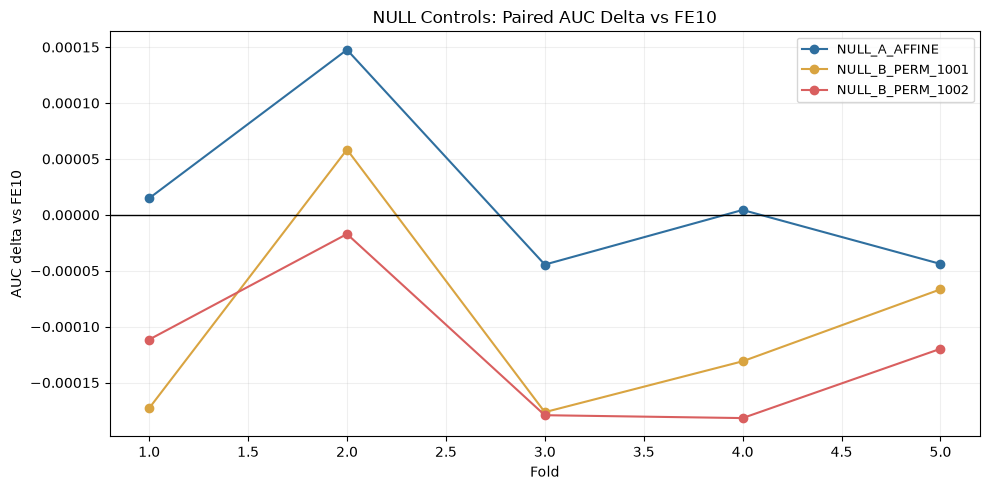

In [8]:
null_pivot = null_folds.pivot(
    index="fold",
    columns="experiment_id",
    values="delta_vs_reference",
)
display(null_pivot)

ax = null_pivot.plot(
    marker="o",
    figsize=(10, 5),
    color={
        "NULL_A_AFFINE": "#2f6f9f",
        "NULL_B_PERM_1001": "#d9a441",
        "NULL_B_PERM_1002": "#d95f5f",
    },
)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("NULL Controls: Paired AUC Delta vs FE10")
ax.set_xlabel("Fold")
ax.set_ylabel("AUC delta vs FE10")
ax.grid(alpha=0.2)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

<a id="r2-null-decision-line" name="r2-null-decision-line"></a>

### 5.2 NULL 校准后的启发式决策线

三组 NULL 各有 5 个 Fold，共 15 个 paired delta；每个 delta 都是同一 Fold 上 `AUC(FE10 + NULL) − AUC(FE10)`。NULL 不提供合法的新信息，因此它们测量的是“只加一个无用列时，AUC delta 会漂多大”。下表按 control 汇总这 15 个 delta：NULL-A 均值接近零，两个 NULL-B 均值为负，说明置换列在当前协议下会带来轻微干扰。

| 实验 | Mean Δ | 正向 Fold | Δ Std (ddof=0；用于门槛) | Mean \|Δ\| | Max \|Δ\| |
|---|---:|---:|---:|---:|---:|
| NULL_A_AFFINE | `+0.000016` | 3/5 | `0.0000703` | `0.000051` | `0.000148` |
| NULL_B_PERM_1001 | `-0.000098` | 1/5 | `0.0000875` | `0.000121` | `0.000176` |
| NULL_B_PERM_1002 | `-0.000122` | 0/5 | `0.0000599` | `0.000122` | `0.000182` |

门槛使用的就是表中三组各自的 `Δ Std (ddof=0)`。不直接混合 15 个 delta，是因为 NULL-A 与 NULL-B 的机制、均值不同；先保留各组 Fold 内波动，再用均方根合并为单 Fold 噪声尺度：

```text
σ_null = √mean(σ_A², σ_B1001², σ_B1002²) ≈ 0.0000734
```

正式判断看的是 5-Fold mean，不是单 Fold。这里有 5 个 delta 在取平均；平均值的随机波动会约缩小为单个 Fold 的 `1 / √5`，所以其噪声近似为 `σ_null / √5 ≈ 0.0000328`。在查看六个第一阶段结果前，预先以其两倍作为保守缓冲：

```text
decision line = 2 × σ_null / √5 ≈ +0.0000657
```

因此，第一阶段继续研究必须同时满足：

1. `mean_delta ≥ +0.0000657`；
2. 至少 `4/5` Fold 为正。

均值门槛检查效应是否超过实测噪声，`4/5` 正向防止单个大 Fold 撑高均值；通过只表示值得进入 LOO / 单特征归因。它是工程 decision rule，不是 p-value 或正式显著性检验：Fold 并不独立、NULL 数量有限，且 NULL-B 存在负偏。

<a id="r2-num-results" name="r2-num-results"></a>

## 6. 第一阶段 6 个实验的完整 5-Fold 证据

<a id="r2-num-analysis" name="r2-num-analysis"></a>

### 6.1 Numerical 分支

这一分支围绕时间预算与屏幕时长的数值关系，完整比较 `R_GROUP`、FE26、FE27 和历史 ratio audit 的 `O_GROUP`。所有实验都在相同的 5 个 Fold 上相对 FE10 计算 paired delta，因此先看 `Mean Δ` 是否超过第 5 节的门槛，再看正向 Fold 数判断方向是否一致。

下表给出四个实验的完整汇总；随后仅对通过第一阶段门槛的 residual family 继续做 LOO 归因。

In [11]:
NUMERICAL_EXPERIMENTS = ["FE27", "R_GROUP", "FE26", "O_GROUP"]

if not ROUND2_SUMMARY_PATH.exists():
    raise FileNotFoundError("未找到 Round 2 summary.csv。")

round2_summary = pd.read_csv(ROUND2_SUMMARY_PATH)
numerical_summary = (
    round2_summary.loc[round2_summary["experiment_id"].isin(NUMERICAL_EXPERIMENTS)]
    .sort_values("mean_delta", ascending=False)
    .copy()
)

numerical_view = numerical_summary[[
    "experiment_id",
    "feature_ids",
    "mean_auc",
    "mean_delta",
    "positive_folds",
    "delta_std",
    "mean_abs_delta",
    "max_abs_delta",
    "mean_best_iteration",
]].rename(columns={
    "experiment_id": "实验",
    "feature_ids": "特征",
    "mean_auc": "平均 AUC",
    "mean_delta": "平均 Δ",
    "positive_folds": "正向 Fold",
    "delta_std": "Δ Std",
    "mean_abs_delta": "Mean |Δ|",
    "max_abs_delta": "Max |Δ|",
    "mean_best_iteration": "平均最佳轮数",
})
display(numerical_view)

,实验,特征,平均 AUC,平均 Δ,正向 Fold,Δ Std,Mean |Δ|,Max |Δ|,平均最佳轮数
0,R_GROUP,FE20 + FE22 + FE25,0.964707,0.000079,5,0.000062,0.000079,0.000167,7601.8
1,O_GROUP,FE28 + FE29,0.964677,0.000048,4,0.000073,0.000064,0.000161,7619.6
2,FE26,FE26,0.964633,0.000004,2,0.000071,0.000047,0.000128,7733.0
4,FE27,FE27,0.964545,-0.000084,0,0.000046,0.000084,0.000126,8268.4


#### 各 Fold 的 paired delta

下表是每个实验相对同一 Fold 的 FE10 的 AUC 差：`AUC(FE10 + 该实验) − AUC(FE10)`。每一行对应一个验证 Fold，每一列对应一个 Numerical 实验；正数表示该 Fold 比 FE10 更高，负数表示更低。上方的汇总表再把这五个 delta 汇成 `Mean Δ` 与正向 Fold 数。


experiment_id,FE26,FE27,O_GROUP,R_GROUP
fold,,,,
1,0.000002,-0.000081,0.000034,0.000167
2,0.000128,-0.000009,0.000161,0.000100
3,-0.000027,-0.000114,-0.000040,0.000038
4,-0.000043,-0.000089,0.000028,0.000005
5,-0.000039,-0.000126,0.000057,0.000085


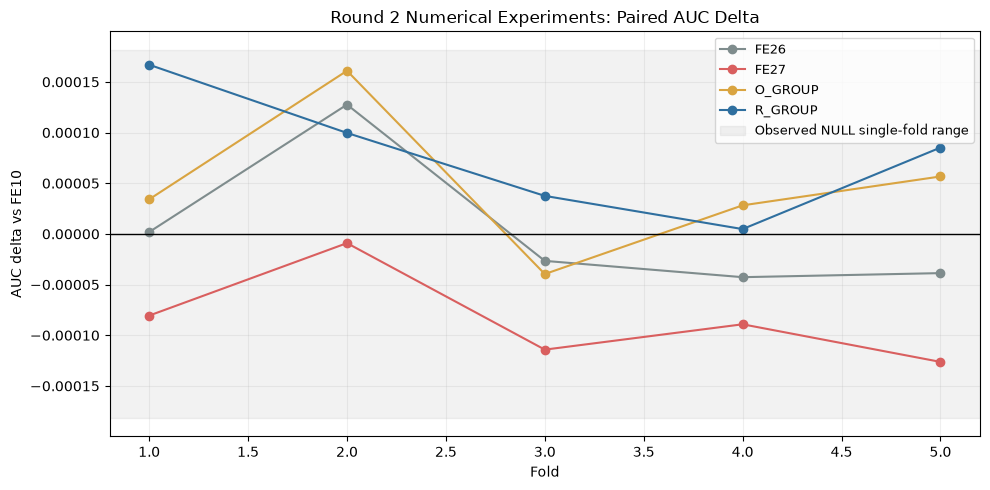

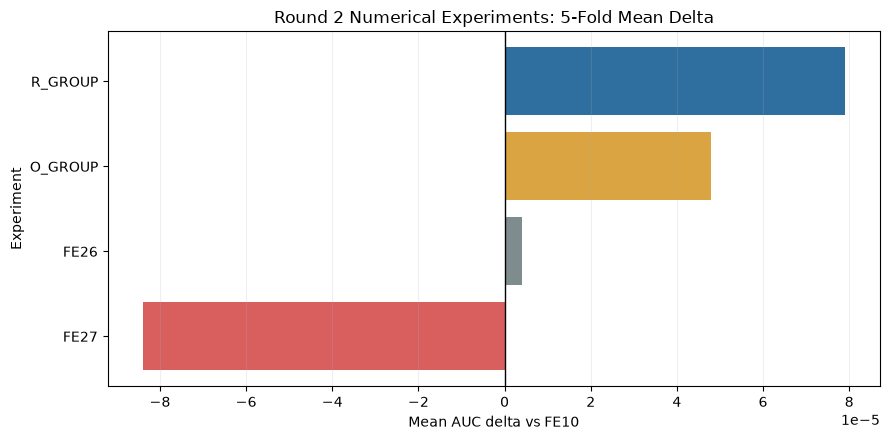

In [12]:
round2_records = []
for path in sorted(ROUND2_RESULTS_DIR.glob("*_fold*.json")):
    result = json.loads(path.read_text(encoding="utf-8"))
    if result.get("experiment_id") in NUMERICAL_EXPERIMENTS:
        round2_records.append(result)

numerical_folds = pd.DataFrame(round2_records)
if len(numerical_folds) != 20:
    raise ValueError(f"Numerical 第一阶段结果应为 20 条，当前为 {len(numerical_folds)} 条。")

numerical_pivot = numerical_folds.pivot(
    index="fold",
    columns="experiment_id",
    values="delta_vs_reference",
)
numerical_pivot.index.name = "Fold"
numerical_pivot.columns.name = "Experiment"
display(numerical_pivot)

NULL_MAX_ABS_DELTA = null_folds["delta_vs_reference"].abs().max()

ax = numerical_pivot.plot(
    marker="o",
    figsize=(10, 5),
    color={
        "R_GROUP": "#2f6f9f",
        "O_GROUP": "#d9a441",
        "FE26": "#7f8c8d",
        "FE27": "#d95f5f",
    },
)
ax.axhspan(
    -NULL_MAX_ABS_DELTA,
    NULL_MAX_ABS_DELTA,
    color="gray",
    alpha=0.10,
    label="Observed NULL single-fold range",
)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Round 2 Numerical Experiments: Paired AUC Delta")
ax.set_xlabel("Fold")
ax.set_ylabel("AUC delta vs FE10")
ax.grid(alpha=0.2)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

mean_delta_plot = numerical_summary.sort_values("mean_delta")
colors = {
    "R_GROUP": "#2f6f9f",
    "O_GROUP": "#d9a441",
    "FE26": "#7f8c8d",
    "FE27": "#d95f5f",
}

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(
    mean_delta_plot["experiment_id"],
    mean_delta_plot["mean_delta"],
    color=mean_delta_plot["experiment_id"].map(colors),
)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Round 2 Numerical Experiments: 5-Fold Mean Delta")
ax.set_xlabel("Mean AUC delta vs FE10")
ax.set_ylabel("Experiment")
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

<a id="r2-cat-results" name="r2-cat-results"></a>

### 6.2 Categorical interaction 分支

CAT_NUM_GROUP 同时加入 FE30、FE31、FE34、FE39、FE40；CAT2_GROUP 同时加入 FE43、FE44、FE45。前者验证 gated categorical × numerical 这一整体实现方向，后者验证显式 categorical × categorical 组合在当前 CatBoost 协议上是否仍有增量。

,实验,特征,平均 AUC,平均 Δ,正向 Fold,Δ Std,平均最佳轮数
3,CAT2_GROUP,FE43 + FE44 + FE45,0.96460,-0.000028,2,0.000048,8494.8
5,CAT_NUM_GROUP,FE30 + FE31 + FE34 + FE39 + FE40,0.96435,-0.000279,0,0.000062,7635.8


experiment_id,CAT2_GROUP,CAT_NUM_GROUP
fold,,
1,-0.000043,-0.000337
2,-0.000053,-0.000298
3,0.000037,-0.000196
4,0.000002,-0.000330
5,-0.000084,-0.000233


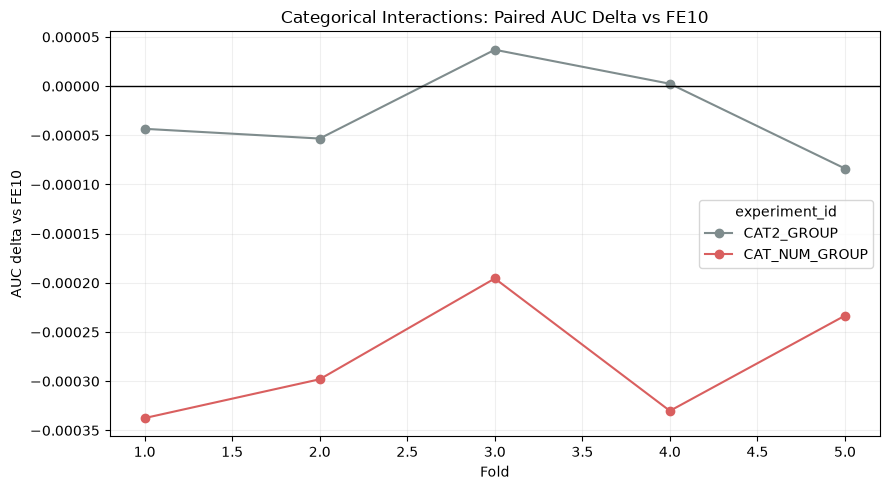

In [13]:
CATEGORICAL_EXPERIMENTS = ["CAT_NUM_GROUP", "CAT2_GROUP"]

categorical_summary = (
    round2_summary.loc[
        round2_summary["experiment_id"].isin(CATEGORICAL_EXPERIMENTS)
    ]
    .sort_values("mean_delta", ascending=False)
    .copy()
)

categorical_view = categorical_summary[[
    "experiment_id",
    "feature_ids",
    "mean_auc",
    "mean_delta",
    "positive_folds",
    "delta_std",
    "mean_best_iteration",
]].rename(columns={
    "experiment_id": "实验",
    "feature_ids": "特征",
    "mean_auc": "平均 AUC",
    "mean_delta": "平均 Δ",
    "positive_folds": "正向 Fold",
    "delta_std": "Δ Std",
    "mean_best_iteration": "平均最佳轮数",
})
display(categorical_view)

categorical_records = []
for path in sorted(ROUND2_RESULTS_DIR.glob("*_fold*.json")):
    result = json.loads(path.read_text(encoding="utf-8"))
    if result.get("experiment_id") in CATEGORICAL_EXPERIMENTS:
        categorical_records.append(result)

categorical_folds = pd.DataFrame(categorical_records)
if len(categorical_folds) != 10:
    raise ValueError(
        f"Categorical 第一阶段结果应为 10 条，当前为 {len(categorical_folds)} 条。"
    )

categorical_pivot = categorical_folds.pivot(
    index="fold",
    columns="experiment_id",
    values="delta_vs_reference",
)
display(categorical_pivot)

ax = categorical_pivot.plot(
    marker="o",
    figsize=(9, 5),
    color={
        "CAT_NUM_GROUP": "#d95f5f",
        "CAT2_GROUP": "#7f8c8d",
    },
)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Categorical Interactions: Paired AUC Delta vs FE10")
ax.set_xlabel("Fold")
ax.set_ylabel("AUC delta vs FE10")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

| 实验 | Mean Δ | 正向 Fold | Δ Std | Fold 1–5 Δ |
|---|---:|---:|---:|---|
| CAT_NUM_GROUP | **`-0.000279`** | **0/5** | `0.000062` | `-0.000337, -0.000298, -0.000196, -0.000330, -0.000233` |
| CAT2_GROUP | `-0.000028` | 2/5 | `0.000048` | `-0.000043, -0.000053, +0.000037, +0.000002, -0.000084` |

CAT_NUM_GROUP 在每个 Fold 都低于 FE10，而且最好的一折仍为 `-0.000196`。因此关闭“这五个 gated features 一起加入”的组合方案，并保持所有 cat × num Reserve 冻结；

CAT2_GROUP 更接近零，表现为轻微负向和方向混合。它不足以唤醒 FE46，却比 CAT_NUM_GROUP 更可能存在成员互相抵消。

<a id="r2-num-decisions" name="r2-num-decisions"></a>

### 6.3 整体决策与解释边界

NULL-A 的五折均值接近零，但单 Fold 绝对漂移最高达到 `0.000148`；两个 permutation seed 均呈负均值，最大绝对漂移达到 `0.000182`。这说明单个 Fold 上 `+0.0001` 左右的变化不能独立证明特征有效。三个 control 的内部波动合并为 `σ_null ≈ 0.0000734` 后，第一阶段使用 `+0.0000657` 与至少 4/5 正向的双条件。

| 实验 | 机制 | Mean Δ | 正向 Fold | 是否过双条件 | 第一阶段动作 |
|---|---|---:|---:|---|---|
| R_GROUP | residual / partial residual | **`+0.000079`** | **5/5** | **是** | 进入 LOO |
| O_GROUP | 历史 ratio Audit | `+0.000048` | 4/5 | 否：均值不足 | 复审结束，不做 LOO |
| FE26 | leisure − work/study | `+0.000004` | 2/5 | 否 | 关闭 linear balance |
| FE27 | daily/weekend screen mean | `-0.000084` | 0/5 | 否 | 关闭 screen mean |
| CAT_NUM_GROUP | gated cat × num | `-0.000279` | 0/5 | 否 | 组合方案关闭，Reserve 冻结 |
| CAT2_GROUP | 显式 cat × cat | `-0.000028` | 2/5 | 否 | group 冻结，FE46 不唤醒 |

#### 为什么只有 R_GROUP 继续

R_GROUP 的五个 delta 全为正，范围约 `+0.000005` 到 `+0.000167`；平均值 `+0.000079` 高于预设决策线 `+0.0000657`。它的证据来自方向一致性，而不是单个异常 Fold。与此同时，平均提升仍然很小，所以正确结论只是“residual family 值得归因”，不能直接保留 FE20、FE22、FE25 全部成员。

O_GROUP 的 4/5 正向说明旧 FE07 / FE16 并非毫无线索，但 `+0.000048` 没有跨过在 NULL 校准后、查看第一阶段结果前固定的均值门槛。为了避免看到边缘结果后放宽标准，本轮不继续 O_GROUP LOO；准确表述是“历史平反证据不足”，不是“FE28 与 FE29 已分别证伪”。

FE26 本身就是单特征实验，均值近零且只有 2/5 正向；FE27 同样是单特征实验，并且 0/5 正向。它们可以直接关闭各自方向，不存在 group 成员互相抵消的解释。

CAT_NUM_GROUP 明显负向，足以否定当前五个 gated features 的联合方案；CAT2_GROUP 接近零，只能说明三个显式组合一起没有增量。

第一阶段最终把 27 个候选定义收敛为一条正式活跃分支：`R_GROUP → LOO`。FE21、FE23、FE24 由 Conditional Reserve 变为 eligible Reserve，但仍需等待 LOO 给出 residual 结构后才决定是否值得测试。

<a id="r2-loo" name="r2-loo"></a>

## 7. R_GROUP LOO 与单特征确认

R_GROUP 通过只说明 `FE20 + FE22 + FE25` 这个 family-level 组合值得继续，不代表三个成员都在贡献。Leave One Out 每次删除一个成员，并同时与同 Fold 的 FE10 和完整 R_GROUP 比较：

| 实验 | 保留成员 | 删除成员 | 主要问题 |
|---|---|---|---|
| R_MINUS_FE20 | FE22 + FE25 | FE20 | 去掉 `D - S` 后信号是否下降？ |
| R_MINUS_FE22 | FE20 + FE25 | FE22 | 去掉 `D - W` 后信号是否下降？ |
| R_MINUS_FE25 | FE20 + FE22 | FE25 | 去掉 `D - G - W` 后信号是否下降？ |

`delta_vs_reference` 判断剩余子集是否仍优于 FE10；`delta_vs_comparison` 直接判断它相对完整 R_GROUP 的变化。若删除某成员后稳定变差，该成员更可能有贡献；若几乎不变或更好，该成员可能冗余或拖累。

LOO 完成后，再把仍可能构成最小方案的 FE22 与 FE25 分别做单特征完整 5-Fold。这个补充实验回答的不是“它们单独有没有信号”这么简单，而是当组合表现相近时，哪个成员能够用更低复杂度保留主要增量。

In [15]:
LOO_SUMMARY_PATH = ROUND2_LOO_DIR / "summary.csv"
SINGLE_SUMMARY_PATH = ROUND2_SINGLE_DIR / "summary.csv"

if not LOO_SUMMARY_PATH.exists():
    raise FileNotFoundError("未找到完整的 R_GROUP LOO summary.csv。")
if not SINGLE_SUMMARY_PATH.exists():
    raise FileNotFoundError("未找到 FE22 / FE25 单特征 summary.csv。")

loo_summary = pd.read_csv(LOO_SUMMARY_PATH)
single_summary = pd.read_csv(SINGLE_SUMMARY_PATH)

loo_view = loo_summary[[
    "experiment_id",
    "feature_ids",
    "mean_delta",
    "positive_folds",
    "delta_std",
    "mean_delta_vs_comparison",
    "better_than_comparison_folds",
    "mean_best_iteration",
]].rename(columns={
    "experiment_id": "实验",
    "feature_ids": "保留特征",
    "mean_delta": "Mean Δ vs FE10",
    "positive_folds": "正向 vs FE10",
    "delta_std": "Δ Std",
    "mean_delta_vs_comparison": "Mean Δ vs R_GROUP",
    "better_than_comparison_folds": "高于 R_GROUP Fold",
    "mean_best_iteration": "平均最佳轮数",
})

single_view = single_summary[[
    "experiment_id",
    "mean_delta",
    "positive_folds",
    "delta_std",
    "min_delta",
    "max_delta",
    "mean_best_iteration",
]].rename(columns={
    "experiment_id": "实验",
    "mean_delta": "Mean Δ vs FE10",
    "positive_folds": "正向 Fold",
    "delta_std": "Δ Std",
    "min_delta": "Min Δ",
    "max_delta": "Max Δ",
    "mean_best_iteration": "平均最佳轮数",
})

display(loo_view)
display(single_view)

,实验,保留特征,Mean Δ vs FE10,正向 vs FE10,Δ Std,Mean Δ vs R_GROUP,高于 R_GROUP Fold,平均最佳轮数
0,R_MINUS_FE20,FE22 + FE25,0.000084,5,0.000061,0.000005,3,7568.8
1,R_MINUS_FE22,FE20 + FE25,0.000074,5,0.000066,-0.000005,3,7989.0
2,R_MINUS_FE25,FE20 + FE22,0.000053,4,0.000081,-0.000026,2,7478.8


,实验,Mean Δ vs FE10,正向 Fold,Δ Std,Min Δ,Max Δ,平均最佳轮数
0,FE25,0.000075,5,0.000034,0.000034,0.000116,8252.8
1,FE22,0.000069,4,0.000087,-0.000016,0.000212,8042.2


### LOO 与单特征的直观对比

三张图都展示 5-Fold 的 `Mean Δ`，便于直接比较删除不同成员后的差距；左图看各子集是否仍超过 FE10 和决策线，中图看删除某成员后相对完整 `R_GROUP` 的变化，右图比较 FE22、FE25 单独加入 FE10 的结果。


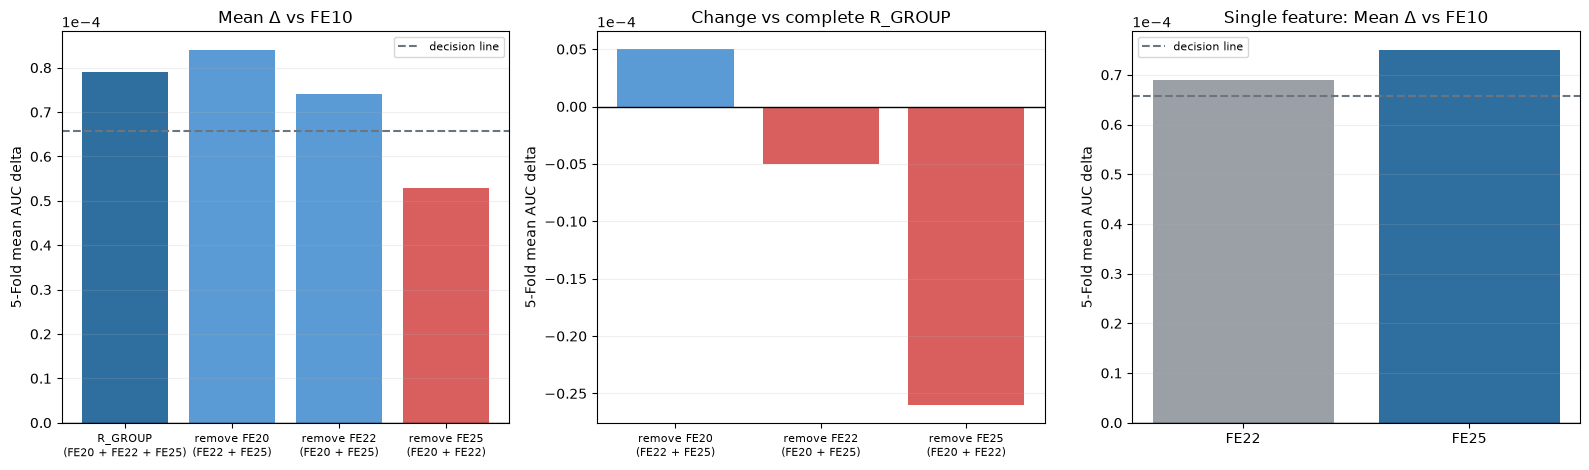

In [16]:
DECISION_LINE = 0.0000657
R_GROUP_MEAN_DELTA = 0.000079

loo_labels = {
    "R_MINUS_FE20": "remove FE20\n(FE22 + FE25)",
    "R_MINUS_FE22": "remove FE22\n(FE20 + FE25)",
    "R_MINUS_FE25": "remove FE25\n(FE20 + FE22)",
}
loo_plot = loo_summary.set_index("experiment_id").loc[list(loo_labels)].reset_index()
loo_plot["label"] = loo_plot["experiment_id"].map(loo_labels)
single_plot = single_summary.set_index("experiment_id").loc[["FE22", "FE25"]].reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

# 1. 完整组与各 LOO 子集相对 FE10 的平均增量。
fe10_values = pd.concat([
    pd.DataFrame({"label": ["R_GROUP\n(FE20 + FE22 + FE25)"], "mean_delta": [R_GROUP_MEAN_DELTA]}),
    loo_plot[["label", "mean_delta"]],
], ignore_index=True)
axes[0].bar(fe10_values["label"], fe10_values["mean_delta"], color=["#2f6f9f", "#5b9bd5", "#5b9bd5", "#d95f5f"])
axes[0].axhline(0, color="black", linewidth=1)
axes[0].axhline(DECISION_LINE, color="#6c757d", linestyle="--", label="decision line")
axes[0].set_title("Mean Δ vs FE10")
axes[0].set_ylabel("5-Fold mean AUC delta")
axes[0].tick_params(axis="x", labelsize=8)
axes[0].legend(fontsize=8)

# 2. 删除后相对完整 R_GROUP 的变化；零表示几乎没有性能差异。
loo_colors = ["#5b9bd5" if value >= 0 else "#d95f5f" for value in loo_plot["mean_delta_vs_comparison"]]
axes[1].bar(loo_plot["label"], loo_plot["mean_delta_vs_comparison"], color=loo_colors)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Change vs complete R_GROUP")
axes[1].set_ylabel("5-Fold mean AUC delta")
axes[1].tick_params(axis="x", labelsize=8)

# 3. FE22 与 FE25 单独加入 FE10 时的平均增量。
single_colors = ["#9aa0a6" if feature == "FE22" else "#2f6f9f" for feature in single_plot["experiment_id"]]
axes[2].bar(single_plot["experiment_id"], single_plot["mean_delta"], color=single_colors)
axes[2].axhline(0, color="black", linewidth=1)
axes[2].axhline(DECISION_LINE, color="#6c757d", linestyle="--", label="decision line")
axes[2].set_title("Single feature: Mean Δ vs FE10")
axes[2].set_ylabel("5-Fold mean AUC delta")
axes[2].legend(fontsize=8)

for ax in axes:
    ax.grid(axis="y", alpha=0.2)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(-4, -4))

plt.tight_layout()
plt.show()


### 7.1 LOO 完整结果

| 实验 | 保留特征 | Mean Δ vs FE10 | 正向 Fold | Mean Δ vs R_GROUP | 解释 |
|---|---|---:|---:|---:|---|
| R_MINUS_FE20 | FE22 + FE25 | **`+0.000084`** | **5/5** | `+0.000005` | 删除 FE20 不损失性能 |
| R_MINUS_FE22 | FE20 + FE25 | `+0.000074` | 5/5 | `-0.000005` | 删除 FE22 也几乎不损失 |
| R_MINUS_FE25 | FE20 + FE22 | `+0.000053` | 4/5 | `-0.000026` | 删除 FE25 后均值下降且波动增大 |

完整 R_GROUP 为 `+0.000079`、5/5 正向。删除 FE20 或 FE22 后，剩余组合仍和完整组处在同一性能档；删除 FE25 后则降到 `+0.000053`、4/5 正向，低于 `+0.0000657` 的均值决策线。LOO 因此把角色分得更清楚：FE20 没有显示条件增量，FE22 可能有信号但并非不可替代，FE25 是最可能承载 R_GROUP 主要收益的成员。

### 7.2 FE22 与 FE25 单特征确认

| 实验 | Mean Δ vs FE10 | 正向 Fold | Δ Std | Min / Max Δ |
|---|---:|---:|---:|---:|
| **FE25 alone** | **`+0.000075`** | **5/5** | **`0.000034`** | `+0.000034 / +0.000116` |
| FE22 alone | `+0.000069` | 4/5 | `0.000087` | `-0.000016 / +0.000212` |

FE25 单独跨过决策线，在 5/5 Fold 上保持正向，而且 Δ Std 只有 `0.000034`；它的增量不是由单个异常 Fold 支撑。FE22 的均值也略高于门槛，但方向为 4/5、波动约为 FE25 的 2.6 倍。

FE22 + FE25 的平均增量为 `+0.000084`，只比 FE25 单独的 `+0.000075` 高约 `0.000009`。这个差值远低于当前能稳定分辨的 noise scale，不能证明多保留 FE22 值得。按“性能近似相同则选择更简单方案”的原则，Round 2 最终保留 **FE25**。

FE25 定义为 `D - G - W`。当四列都存在时，它等于 `FE10 + S`；同时它只要求 D、G、W 非缺失，不依赖 social_media_hours。因此它可能既为有限深度的树提供更容易切分的坐标轴，也在 FE10 缺失时覆盖更多样本。

最终 residual verdict：

- **FE25：Keep**，作为 FE10 之外的最终增量特征；
- **FE22：Hold / redundant**，单独有弱正信号，但在 FE25 条件下没有可辨识增量；
- **FE20：Drop / redundant**；
- **FE21、FE23、FE24：停止扩展**，保留在 backlog，不再为同类高度相关变换追逐 `1e-5` 量级差异。

<a id="r2-final-model" name="r2-final-model"></a>

## 8. 最终模型与提交文件

最终 Feature Set 为 **FE10 + FE25**。FE25 五个 Fold 的最佳轮数为 `7396、8853、8554、7631、8830`，均值 `8252.8`，因此全量模型固定训练 **8253 轮**，不再设置 `eval_set` 或 early stopping。其余显式模型参数、random seed、thread count 与 CV 实验保持一致。

<a id="r2-final-data" name="r2-final-data"></a>

### 8.1 准备全量数据与最终特征

In [17]:
from pathlib import Path
import sys

import pandas as pd
from catboost import CatBoostClassifier
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.round2_features import make_round2_features

DATA_DIR = PROJECT_ROOT / "data"
SUBMISSION_DIR = PROJECT_ROOT / "submissions"
FINAL_EXPERIMENT_ID = "FE25"
FINAL_ITERATIONS = 8253

train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

X_final = train.drop(columns=["addicted_label", "id"]).copy()
y_final = train["addicted_label"].copy()
X_test_final = test.drop(columns=["id"]).copy()
original_columns = list(X_final.columns)

X_final = make_round2_features(X_final, FINAL_EXPERIMENT_ID)
X_test_final = make_round2_features(X_test_final, FINAL_EXPERIMENT_ID)
added_columns = [col for col in X_final.columns if col not in original_columns]
expected_added_columns = [
    "unknown_activity_time",
    "screen_minus_gaming_work_study",
]

if added_columns != expected_added_columns:
    raise ValueError(f"最终新增特征不符合预期：{added_columns}")
if list(X_final.columns) != list(X_test_final.columns):
    raise ValueError("训练集与测试集的最终特征列不一致。")
if not test["id"].equals(sample_submission["id"]):
    raise ValueError("test.csv 与 sample_submission.csv 的 id 顺序不一致。")

cat_cols = [
    "gender",
    "stress_level",
    "academic_work_impact",
]

for col in cat_cols:
    X_final[col] = X_final[col].fillna("Missing")
    X_test_final[col] = X_test_final[col].fillna("Missing")

print("训练集特征形状：", X_final.shape)
print("测试集特征形状：", X_test_final.shape)
print("最终 Feature Set：FE10 + FE25")
print("新增特征：", added_columns)
print("全量训练轮数：", FINAL_ITERATIONS)

训练集特征形状： (691369, 14)
测试集特征形状： (296302, 14)
最终 Feature Set：FE10 + FE25
新增特征： ['unknown_activity_time', 'screen_minus_gaming_work_study']
全量训练轮数： 8253


<a id="r2-final-training" name="r2-final-training"></a>

### 8.2 训练最终模型

In [18]:
final_model = CatBoostClassifier(
    iterations=FINAL_ITERATIONS,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    thread_count=10,
    verbose=500,
    allow_writing_files=False,
)

final_model.fit(
    X_final,
    y_final,
    cat_features=cat_cols,
)

feature_importance_final = (
    pd.DataFrame({
        "特征": X_final.columns,
        "重要性": final_model.feature_importances_,
    })
    .sort_values("重要性", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance_final.head(15))

0:	total: 149ms	remaining: 20m 32s
500:	total: 48.1s	remaining: 12m 24s
1000:	total: 1m 33s	remaining: 11m 19s
1500:	total: 2m 20s	remaining: 10m 32s
2000:	total: 3m 7s	remaining: 9m 46s
2500:	total: 3m 54s	remaining: 9m
3000:	total: 4m 43s	remaining: 8m 16s
3500:	total: 5m 31s	remaining: 7m 29s
4000:	total: 6m 17s	remaining: 6m 41s
4500:	total: 7m 3s	remaining: 5m 53s
5000:	total: 7m 50s	remaining: 5m 5s
5500:	total: 8m 39s	remaining: 4m 20s
6000:	total: 9m 27s	remaining: 3m 33s
6500:	total: 10m 14s	remaining: 2m 45s
7000:	total: 11m 3s	remaining: 1m 58s
7500:	total: 11m 50s	remaining: 1m 11s
8000:	total: 12m 38s	remaining: 23.9s
8252:	total: 13m 1s	remaining: 0us


,特征,重要性
0,weekend_screen_time,21.604960
1,daily_screen_time_hours,21.505114
2,social_media_hours,15.062185
3,notifications_per_day,13.504071
4,app_opens_per_day,11.481295
5,work_study_hours,3.988207
6,screen_minus_gaming_work_study,3.193504
7,gaming_hours,3.051301
8,unknown_activity_time,2.623929
9,sleep_hours,2.253189


<a id="r2-final-submission" name="r2-final-submission"></a>

### 8.3 生成、检查并保存提交文件

In [19]:
test_pred_final = final_model.predict_proba(X_test_final)[:, 1]

submission_final = sample_submission.copy()
submission_final["addicted_label"] = test_pred_final

submission_check = pd.DataFrame({
    "检查项": [
        "提交行数",
        "ID 是否唯一",
        "ID 是否与 test 顺序一致",
        "预测缺失数",
        "最小预测概率",
        "最大预测概率",
    ],
    "结果": [
        len(submission_final),
        submission_final["id"].is_unique,
        submission_final["id"].equals(test["id"]),
        submission_final["addicted_label"].isna().sum(),
        submission_final["addicted_label"].min(),
        submission_final["addicted_label"].max(),
    ],
})

if len(submission_final) != len(test):
    raise ValueError("提交文件行数与测试集不一致。")
if not submission_final["id"].is_unique:
    raise ValueError("提交文件存在重复 ID。")
if submission_final["addicted_label"].isna().any():
    raise ValueError("提交预测中存在缺失值。")
if not submission_final["addicted_label"].between(0, 1).all():
    raise ValueError("提交预测超出 [0, 1]。")

SUBMISSION_DIR.mkdir(exist_ok=True)
submission_path = (
    SUBMISSION_DIR
    / "catboost_v4_fe10_fe25_8253iter.csv"
)
submission_final.to_csv(submission_path, index=False)

display(submission_final.head())
display(submission_check)
print("提交文件已保存到：", submission_path)

,id,addicted_label
0,691369,0.999530
1,691370,0.954072
2,691371,0.903862
3,691372,0.991587
4,691373,0.998873


,检查项,结果
0,提交行数,296302
1,ID 是否唯一,True
2,ID 是否与 test 顺序一致,True
3,预测缺失数,0
4,最小预测概率,0.000027
5,最大预测概率,1.0


提交文件已保存到： /Users/c.c./Developer/Competitions/predicting-smartphone-addiction/submissions/catboost_v4_fe10_fe25_8253iter.csv


<a id="r2-num-next" name="r2-num-next"></a>

## 9. Feature Engineering 最终结论

Feature Engineering 已完成从候选筛选、NULL 校准、family-level 5-Fold 到 LOO 与单特征确认的闭环。Round 2 最终只在 FE10 上新增 **FE25（`D - G - W`）**。

| Run | Feature Set | 5-Fold AUC | 相对上一版本的本地增量 | Public LB | 相对上一版本的 LB 增量 |
|---|---|---:|---:|---:|---:|
| v2 | 原始特征 | `0.964007 ± 0.000473` | — | `0.96538` | `+0.01311` vs v1 |
| v3 | FE10 | `0.964629 ± 0.000523` | `+0.000621` vs v2 | `0.96606` | `+0.00068` vs v2 |
| **v4** | **FE10 + FE25** | **`0.964704 ± 0.000522`** | **`+0.000075` vs v3** | **`0.96617`** | **`+0.00011` vs v3** |

Round 2 的 LOO 与单特征确认最终将方案收敛为 **FE10 + FE25**；全量模型按 FE25 五折最佳轮数均值 `8252.8` 固定训练 **8253 iterations**。

最终提交文件 `catboost_v4_fe10_fe25_8253iter.csv` 获得 Public LB **0.96617**，较 v3 提升 **+0.00011**，与本地 paired-CV 的正向结论一致；相较无特征工程的 v2，Public LB 累计提升 **+0.00079**。

![CatBoost v4 with FE10 + FE25 — Public LB 0.96617](../images/catboost_v4_fe10_fe25_8253_public_lb.png)

*Submission result for `catboost_v4_fe10_fe25_8253iter.csv`.*

`04_feature_engineering.ipynb` 找到 FE10，本 Notebook 进一步确认 FE25，并以 Kaggle Public LB 的小幅提升完成外部一致性验证。特征工程到这里结束；下一阶段将转向模型配置、LightGBM / XGBoost、OOF 预测与 Ensemble。